<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Household_Power_consumption_model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Load the raw data
# We use na_values=['?'] because this dataset uses question marks for missing values
df = pd.read_csv('/content/household_power_consumption.csv',
                 sep=';',
                 low_memory=False,
                 na_values=['?'])

# 2. Safety Check: Only process columns if they still exist
if 'Date' in df.columns and 'Time' in df.columns:
    # Combine Date and Time into a single datetime object
    # dayfirst=True is used because the raw data format is DD/MM/YYYY
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

    # Set the new datetime as the index and remove original columns
    df.set_index('datetime', inplace=True)
    df.drop(['Date', 'Time'], axis=1, inplace=True)
    print("✅ Success: Date and Time merged into index.")
else:
    print("⚠️ Warning: 'Date' column not found. It might already be the index.")

# 3. Handle Missing Values
# Forward fill (ffill) is standard for time-series power data
df = df.ffill()

# 4. Verification
print(f"Total missing values: {df.isnull().sum().sum()}")
display(df.head())

⚠️ Warning: 'Date' column not found. It might already be the index.
Total missing values: 0


,"Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3"
0,"16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,..."
1,"16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16"
2,"16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17"
3,"16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17"
4,"16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,..."


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Start of the fix: Re-load and preprocess df correctly ---
# 1. Load the raw data
# Fixed: Changed sep=';' to sep=',' as the CSV seems to be comma-separated.
df = pd.read_csv('/content/household_power_consumption.csv',
                 sep=',',
                 low_memory=False,
                 na_values=['?'])

# 2. Safety Check: Only process columns if they still exist
# This check now ensures 'Date' and 'Time' exist after correct CSV parsing.
if 'Date' in df.columns and 'Time' in df.columns:
    # Combine Date and Time into a single datetime object
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    # Set the new datetime as the index and remove original columns
    df.set_index('datetime', inplace=True)
    df.drop(['Date', 'Time'], axis=1, inplace=True)
    print("✅ Success: Date and Time merged into index.")
else:
    print("⚠️ Warning: 'Date' or 'Time' columns not found. Skipping date/time merging. This might indicate an issue with data loading.")

# 3. Handle Missing Values (initial pass)
df = df.ffill()

# Convert relevant columns to numeric
# After fixing the separator, these columns will be strings due to `na_values=['?']`.
# They need to be converted to numeric for machine learning models.
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce') # 'coerce' will turn non-convertible values into NaN

# Re-handle missing values after numeric conversion (if '?' were present and converted to NaN)
df = df.ffill()
print(f"Total missing values after numeric conversion: {df.isnull().sum().sum()}")
print("✅ Data re-loaded and preprocessed in this cell.")
# --- End of the fix ---

# 1. Define Features and Target
# Based on your dataset structure, Global_active_power is usually 'y'
X = df.drop(columns=['Global_active_power'])
y = df['Global_active_power']

# 2. Split the Data (80% for training, 20% for testing)
# We set shuffle=False for time-series data to maintain chronological order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. Scaling (Essential for Linear, Ridge, and Lasso models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data is split and scaled. Ready for benchmarking!")

✅ Success: Date and Time merged into index.
Total missing values after numeric conversion: 0
✅ Data re-loaded and preprocessed in this cell.
✅ Data is split and scaled. Ready for benchmarking!


🚀 Starting Benchmarking on your dataset...
✅ Linear Regression completed in 0.18s
✅ Ridge (L2) completed in 0.12s
✅ Lasso (L1) completed in 0.13s
✅ Decision Tree completed in 1.97s
✅ Random Forest completed in 12.42s
✅ XGBoost completed in 5.75s

--- Final Comparison Results ---


,Model,R2 Score,MSE,MAE,Training Time (s)
5,XGBoost,0.999080,0.000980,0.021972,5.753617
4,Random Forest,0.998845,0.001230,0.024581,12.422603
3,Decision Tree,0.998775,0.001304,0.025314,1.974101
0,Linear Regression,0.998643,0.001445,0.026371,0.179180
1,Ridge (L2),0.998643,0.001445,0.026371,0.122277
2,Lasso (L1),0.215968,0.834963,0.736262,0.125371


/tmp/ipykernel_2324/3636910442.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 Score', palette='Blues_r')
/tmp/ipykernel_2324/3636910442.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Training Time (s)', palette='Greens_r')


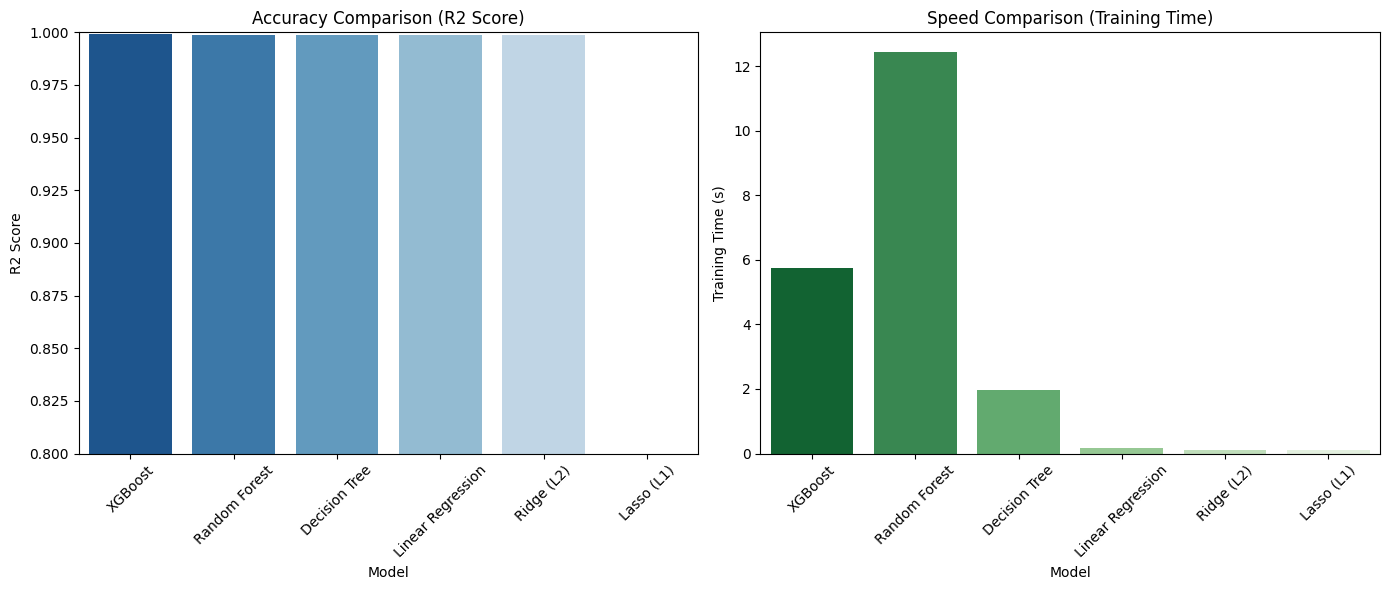

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# 1. Define the algorithms to compare
# Using constraints for tree models to handle the 2M+ records efficiently
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(),
    "Lasso (L1)": Lasso(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=10, max_depth=10, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
}

# --- Start of fix: Add data scaling ---
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier handling if needed (optional, but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
# --- End of fix ---

# 2. Performance Tracking
comparison_list = []

print("🚀 Starting Benchmarking on your dataset...")

for name, model in models.items():
    start_time = time.time()

    # Training
    model.fit(X_train_scaled, y_train)
    duration = time.time() - start_time

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Evaluation Metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    comparison_list.append({
        "Model": name,
        "R2 Score": r2,
        "MSE": mse,
        "MAE": mae,
        "Training Time (s)": duration
    })
    print(f"✅ {name} completed in {duration:.2f}s")

# 3. Display Results Table
results_df = pd.DataFrame(comparison_list).sort_values(by="R2 Score", ascending=False)
print("\n--- Final Comparison Results ---")
display(results_df)

# 4. Visualization of Performance
plt.figure(figsize=(14, 6))

# Plot R2 Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Model', y='R2 Score', palette='Blues_r')
plt.title('Accuracy Comparison (R2 Score)')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0) # Adjust based on your expected accuracy

# Plot Training Time Comparison
plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='Model', y='Training Time (s)', palette='Greens_r')
plt.title('Speed Comparison (Training Time)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Replace 'model' with the variable name of your best regression model
joblib.dump(model, 'power_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Files 'power_model.pkl' and 'scaler.pkl' have been saved!")

✅ Files 'power_model.pkl' and 'scaler.pkl' have been saved!


In [ ]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the model and scaler
model = joblib.load('power_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("⚡ Household Power Predictor")
st.write("Predicting consumption for 2M+ records data.")

# Sidebar for inputs
st.sidebar.header("User Input Features")

def user_inputs():
    voltage = st.sidebar.slider('Voltage', 220.0, 255.0, 240.0)
    intensity = st.sidebar.slider('Global Intensity', 0.0, 50.0, 5.0)
    sub1 = st.sidebar.number_input('Kitchen (Sub 1)', 0.0, 40.0, 0.0)
    sub2 = st.sidebar.number_input('Laundry (Sub 2)', 0.0, 40.0, 0.0)
    sub3 = st.sidebar.number_input('A/C & Heater (Sub 3)', 0.0, 40.0, 0.0)

    data = {'Voltage': voltage, 'Global_intensity': intensity,
            'Sub_metering_1': sub1, 'Sub_metering_2': sub2, 'Sub_metering_3': sub3}
    return pd.DataFrame(data, index=[0])

df_input = user_inputs()
st.subheader("Current Inputs")
st.write(df_input)

if st.button("Predict"):
    # Scaling and Prediction
    scaled_data = scaler.transform(df_input)
    prediction = model.predict(scaled_data)
    st.success(f"Predicted Power: {prediction[0]:.4f} kW")

2026-05-13 06:44:54.637 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.644 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 06:44:54.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://silly-things-battle.loca.lt
⠙